# Figures for Wingert, Parida et al. 2026

Code to generate figures in Wingert et al. (2026) Convolutional neural network models describe the encoding subspace of local circuits in auditory cortex. *Nature Neuroscience*. In press.

## Requirements

* python >= 3.9
* NEMS (Neural Encoding Model System) Library --
  * Download from https://github.com/LBHB/NEMS
  * installed with Tensorflow support: `pip install /<path>/<to>/NEMS[tf]`
* Additional libraries: `seaborn`, `statsmodels`


In [1]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import statsmodels.formula.api as smf
import seaborn as sns
from scipy.stats import wilcoxon, linregress

# Functions from NEMS library
from nems.tools.recording import load_recording, average_away_epoch_occurrences
from nems.tools.json import load_model
from nems.preprocessing.normalization import log_compress

# special functions used to generate plots in this study
import aud_ss_tools

font_size=8
params = {'legend.fontsize': font_size-2,
          'figure.figsize': (8, 6),
          'axes.labelsize': font_size,
          'axes.titlesize': font_size,
          'axes.spines.right': False,
          'axes.spines.top': False,
          'axes.prop_cycle': mpl.cycler(color=aud_ss_tools.CB_color_cycle),
          'xtick.labelsize': font_size,
          'ytick.labelsize': font_size,
          'font.family': 'sans-serif',
          'font.sans-serif': ['Arial', 'DejaVu Sans'],
          'image.interpolation': 'none',
          'pdf.fonttype': 42,
          'ps.fonttype': 42}
plt.rcParams.update(params)

## Set up paths to data/model files.
`data_path` should point to the folder downloaded from Zenodo that contains the `models` and `recordings` folders.

In [2]:
# by default, data folders are subdirectories of the folder containing this notebook
data_path = '.'

model_path_cnn = os.path.join(data_path,'models','CNN')
model_path_ln = os.path.join(data_path,'models','LN')
rec_path = os.path.join(data_path, 'recordings')

Wrapper to load trained models and data associated with a recording site

In [3]:
def load_data(siteid='PRN018a'):
    """
    Load data associated with recording site siteid
    
    Hard-coded specifically to work with exported model/recordings associated with this paper.
    """
    modelpath = glob.glob(model_path_cnn+'/'+siteid+'*')[0]
    modelfile = os.path.join(modelpath, 'modelspec.json')
    print(f"Loading trained CNN model from {modelfile}")
    modelspec = load_model(modelfile)
    
    modelpathln = glob.glob(model_path_ln+'/'+siteid+'*')[0]
    modelfile = os.path.join(modelpathln, 'modelspec.json')
    print(f"Loading trained LN model from {modelfile}")
    modelspecln = load_model(modelfile)

    recfile = glob.glob(rec_path+'/'+siteid+'*')[0]
    print(f"Loading stimulus/spike data from {recfile}")
    rec = load_recording(recfile)
    
    rec['stim'] = rec['stim'].rasterize().transform(log_compress, 'stim')
    rec['stim'] = rec['stim'].normalize('minmax')
    rec['resp'] = rec['resp'].rasterize().normalize('minmax')
    
    epoch_regex="^STIM_"
    est, val = rec.split_using_epoch_occurrence_counts(epoch_regex=epoch_regex)
    est = average_away_epoch_occurrences(est, epoch_regex=epoch_regex)
    val = average_away_epoch_occurrences(val, epoch_regex=epoch_regex)
    
    pred = modelspec.predict(est['stim']._data.T)
    est['pred'] = est['resp']._modified_copy(data=pred.T)
    pred = modelspec.predict(val['stim']._data.T)
    val['pred'] = val['resp']._modified_copy(data=pred.T)

    return modelspec, modelspecln, est, val

# Fig 1 - Example subspace projections and model prediction

Also plot second cell from Extended Data Fig. 2

In [4]:
siteid = 'LMD033a'
modelspec, modelspecln, est, val = load_data(siteid=siteid)

Loading trained CNN model from ./models/CNN/LMD033a_343_gtgram.fs100.ch32-ld-norm.l1-sev_wc.Nx1x90.g-fir.15x1x90-relu.90.s...-566216852612303372/modelspec.json
Loading trained LN model from ./models/LN/LMD033a_343_gtgram.fs100.ch32-ld-norm.l1-sev_wc.Nx1x120.g-fir.25x1x120-wc.120x...8258436087926869869/modelspec.json
Loading stimulus/spike data from ./recordings/LMD033a_2d3e053f8101328e7a036fb0e985293b98305547.tgz


## Aside: plot stimulus/resp/pred for all units in recording site

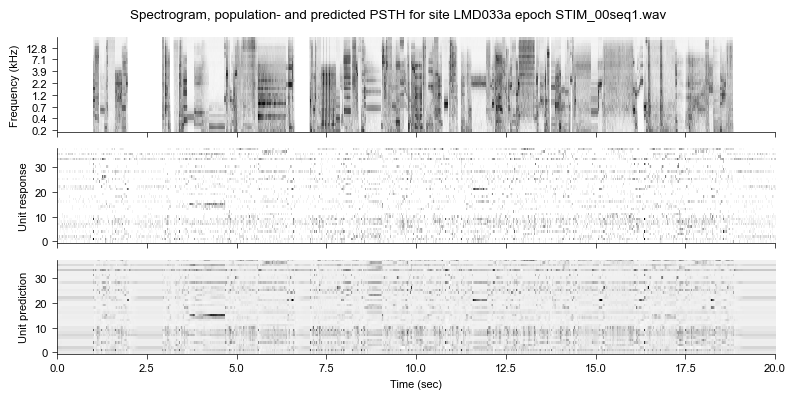

In [5]:
stim_epochs = val['stim'].epoch_names_matching("STIM_")

fs=val['stim'].fs
e=stim_epochs[0]

s = val['stim'].extract_epoch(e)[0]
r = val['resp'].extract_epoch(e).mean(axis=0)
p = val['pred'].extract_epoch(e).mean(axis=0)

f,ax=plt.subplots(3,1,sharex='col', figsize=(8,4))

loglo, loghi = np.log2(modelspec.meta['f_min']), np.log2(modelspec.meta['f_max'])
f_steps = np.round(2**np.linspace(loglo,loghi,s.shape[0])/1000,1)
T_max=s.shape[1]/fs
ax[0].imshow(s, aspect='auto', cmap='gray_r', origin='lower', extent=[0, T_max, -0.5, s.shape[0]-0.5])
ax[0].set_yticks(np.arange(0,s.shape[0],4), f_steps[np.arange(0,s.shape[0],4)])
ax[0].set_ylabel('Frequency (kHz)')
ax[1].imshow(r, aspect='auto', cmap='gray_r', extent=[0, T_max, -0.5, r.shape[0]-0.5])
ax[1].set_ylabel('Unit response')
ax[2].imshow(p, aspect='auto', cmap='gray_r', extent=[0, T_max, -0.5, p.shape[0]-0.5])
ax[2].set_ylabel('Unit prediction')
ax[2].set_xlabel('Time (sec)')
f.suptitle(f"Spectrogram, population- and predicted PSTH for site {siteid} epoch {e}")
plt.tight_layout()

[aud_ss_tools INFO] subspace pred/project for 9, LMD033a-A-300-2
[aud_ss_tools INFO] subspace pred/project for 10, LMD033a-A-304-1


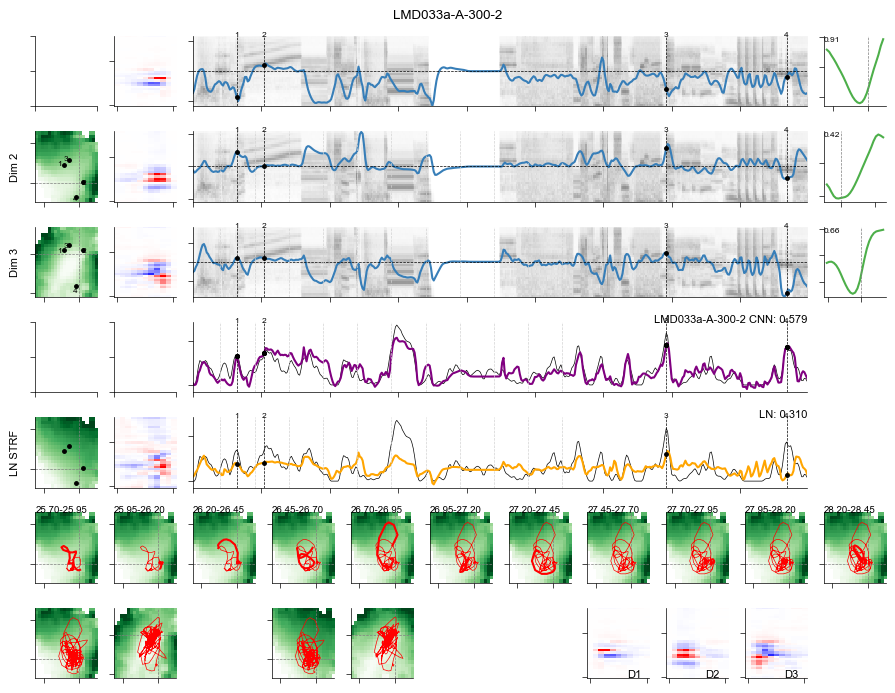

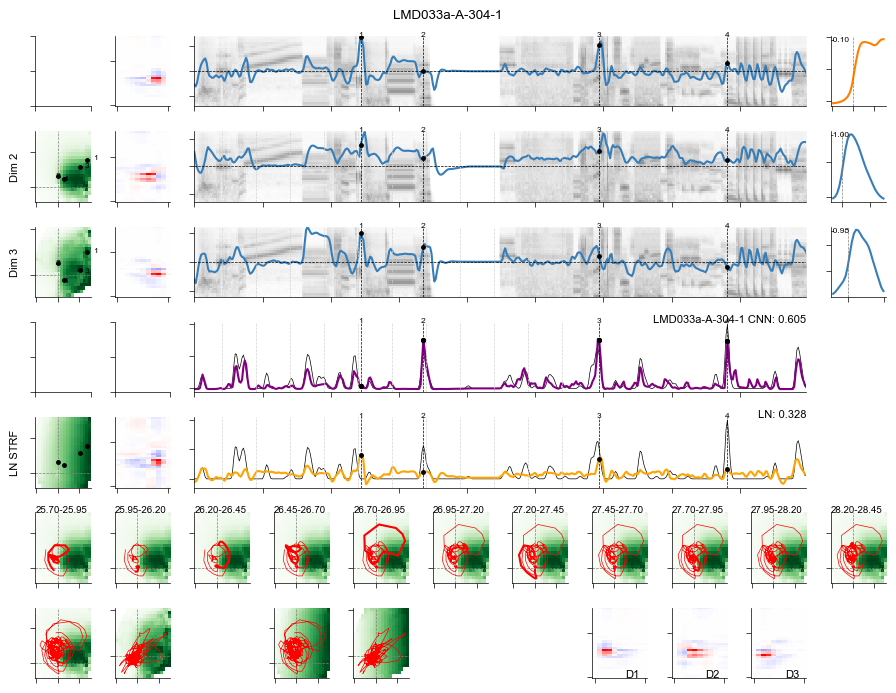

In [6]:
cell_list = ['LMD033a-A-300-2','LMD033a-A-304-1',]

# define range of time samples to plot and time points to highlight.
T1, T2 = 2550, 3000
t_highlight = [[2582, 2602, 2896, 2984], [2672, 2718, 2847, 2941]] 

emax=200000 # number of timepoints to include in heatmap calculation. Make smaller to run faster

for i,cellid in enumerate(cell_list):
    f = aud_ss_tools.plot_dpc_proj(cell_list=[cellid], use_val=True, modelspec2=modelspecln, 
                            T1=T1, T2=T2, D=11, ex_pct=0.05, emax=emax, t_highlight=t_highlight[i],
                            est=est, val=val, modelspec=modelspec)

# Fig 2 - Comparison of prediction accuracy between architectures

* `LN32` baseline linear-nonlinear model
* `CNN32-bsg` CNN-based model
* `dfit.v95.u15` subspace model fit using 95%-variance-explained subspace
* `dfit.v95.pol1`, `dfit.v95.pol2` - subspace models with constrained linear (pol1) or 2nd order polynomial (pol2)

In [7]:
ssdf = pd.read_csv('model_performance.csv', index_col=0)
shortnameslong = ['LN32', 'CNN32-bsg', 
                  'dfit.v80.u15', 'dfit.v90.u15', 'dfit.v95.u15', 'dfit.v99.u15', 
                  'dfit.v95.pol1', 'dfit.v95.pol2']

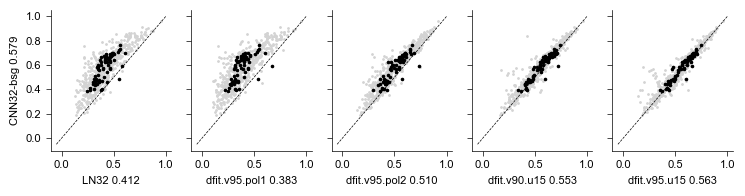

In [8]:
sms=ssdf.loc[ssdf['goodpred']].copy()
sms = sms.groupby('siteid')[shortnameslong].median()
scattermax = 1
s=10

f,ax=plt.subplots(1,5,figsize=(7.5,2), sharey='row', sharex='row')
pairs = [(shortnameslong[0], shortnameslong[1]), ('dfit.v95.pol1', shortnameslong[1]), 
         ('dfit.v95.pol2', shortnameslong[1]), ('dfit.v90.u15', shortnameslong[1]), ('dfit.v95.u15', shortnameslong[1]), 
        ]
sall = ssdf.dropna().loc[ssdf['goodpred']].copy()

for i,(a,b) in enumerate(pairs):
    x, y = sall[a].values[::5], sall[b].values[::5]
    ax[i].scatter(x,y,s=1,color='lightgray')
    aud_ss_tools.scatter_comp(sms[a],sms[b],n1=a, n2=b, s=s, hist_range=(-0.05,scattermax), ax=ax[i]);
    if i>0:
        ax[i].set_ylabel('')
plt.tight_layout()

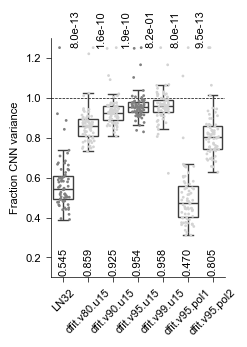

In [9]:
s=ssdf.loc[ssdf['goodpred']].copy()
s[shortnameslong]=s[shortnameslong]**2
d=s[shortnameslong[1]].copy()
for c in shortnameslong:
    s[c] = s[c]/ d

sms=s.copy()
sms = sms.groupby('siteid')[shortnameslong].median()

si = sms.copy()
sm = si.median()
si_clipped = si.clip(0,1.25)

cols = [sms.columns[0]] + list(sms.columns[2:])
colors = ['gray','lightgray','lightgray','gray','lightgray','lightgray','lightgray']

f,ax=plt.subplots(figsize=(2.5,3.5))

ax.axhline(1, color='k', linestyle='--', lw=0.5);
sns.stripplot(data=si_clipped[cols], s=2, palette=colors, jitter=0.25, ax=ax)
sns.boxplot(data=si_clipped[cols], color='w', showfliers=False, ax=ax)

ax.set_xticks(np.arange(len(cols)), cols, rotation=45)
ax.set_ylim([0.1,1.3])
for i,c in enumerate(cols):
    #ax.text(i,1.25,np.sum(si_clipped[c]==1.25), ha='center')
    ax.text(i,0.12,f"{sm[c]:.3f}", ha='center', rotation=90)
    
    if i in [1,2,3,4]:
        t,p = wilcoxon(si[cols[i]],si[cols[i-1]])
        ax.text(i-0.5,1.25, f"{p:.1e}", ha='center', va='bottom', rotation=90)
    elif i==5:
        t,p = wilcoxon(si[cols[i]],si[cols[0]])
        ax.text(i-0.5,1.25, f"{p:.1e}", ha='center', va='bottom', rotation=90)
    elif i==6:
        t,p = wilcoxon(si[cols[i]],si[cols[3]])
        ax.text(i-0.5,1.25, f"{p:.1e}", ha='center', va='bottom', rotation=90)

ax.set_ylabel('Fraction CNN variance')
plt.tight_layout()

# Fig 3 - Example subspace filters and SSRFs

In [10]:
modelspec, modelspecln, est, val = load_data(siteid="PRN018a")

Loading trained CNN model from ./models/CNN/PRN018a_343_gtgram.fs100.ch32-ld-norm.l1-sev_wc.Nx1x90.g-fir.15x1x90-relu.90.s...-555758176447059772/modelspec.json
Loading trained LN model from ./models/LN/PRN018a_343_gtgram.fs100.ch32-ld-norm.l1-sev_wc.Nx1x120.g-fir.25x1x120-wc.120x...1487892261124758000/modelspec.json
Loading stimulus/spike data from ./recordings/PRN018a_45a79ef76a6bbcf3149ef9797d860bd8ff4d8f50.tgz


In [11]:
rs_cellids = ["PRN018a-070-1","PRN018a-062-1","PRN018a-046-1","PRN018a-043-1","PRN018a-024-1","PRN018a-383-1","PRN018a-379-1","PRN018a-363-1"]
ns_cellids = ["PRN018a-059-1","PRN018a-041-1","PRN018a-042-1","PRN018a-039-1","PRN018a-029-1","PRN018a-026-1","PRN018a-011-1","PRN018a-012-1"]
df = pd.read_csv('cell_list.csv', index_col=0)

In [12]:
import importlib
importlib.reload(aud_ss_tools)

<module 'aud_ss_tools' from '/auto/users/svd/projects/pub_data_share/wingert_2025/aud_ss_tools.py'>

[aud_ss_tools INFO] ['PRN018a-070-1', 'PRN018a-062-1', 'PRN018a-046-1', 'PRN018a-043-1', 'PRN018a-024-1', 'PRN018a-383-1', 'PRN018a-379-1', 'PRN018a-363-1']: [32, 30, 22, 21, 15, 39, 38, 36]
[aud_ss_tools INFO] ** Recording raw:
[aud_ss_tools INFO]    SS proj oi=0 o=32 PRN018a-070-1 pc_count=3:
[aud_ss_tools INFO]    SS proj oi=1 o=30 PRN018a-062-1 pc_count=3:
[aud_ss_tools INFO]    SS proj oi=2 o=22 PRN018a-046-1 pc_count=3:
[aud_ss_tools INFO]    SS proj oi=3 o=21 PRN018a-043-1 pc_count=3:
[aud_ss_tools INFO]    SS proj oi=4 o=15 PRN018a-024-1 pc_count=3:
[aud_ss_tools INFO]    SS proj oi=5 o=39 PRN018a-383-1 pc_count=3:
[aud_ss_tools INFO]    SS proj oi=6 o=38 PRN018a-379-1 pc_count=3:
[aud_ss_tools INFO]    SS proj oi=7 o=36 PRN018a-363-1 pc_count=3:
[aud_ss_tools INFO] stim len 500000 ds to 500000.0 to match resp len 500000
[aud_ss_tools INFO] (212000, 32) (8, 3, 212000)
[aud_ss_tools INFO] (212000, 32) (8, 3, 212000)
[aud_ss_tools INFO] 1/8 cid=32 cellid=PRN018a-070-1
[aud_ss_too

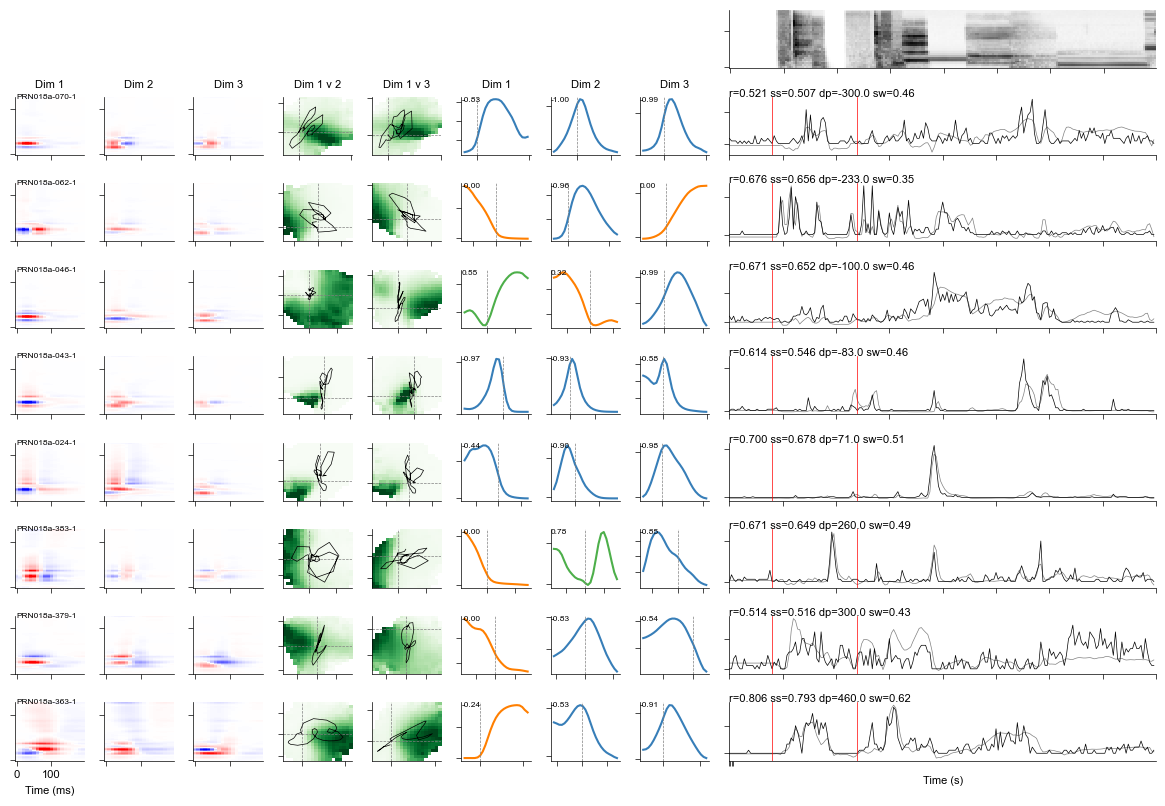

In [13]:
f=aud_ss_tools.plot_dpc_rows(modelspec=modelspec, est=est, val=val, emax=200000, w=11, df=df, cell_list=rs_cellids, verbose=False);

[aud_ss_tools INFO] ['PRN018a-059-1', 'PRN018a-041-1', 'PRN018a-042-1', 'PRN018a-039-1', 'PRN018a-029-1', 'PRN018a-026-1', 'PRN018a-011-1', 'PRN018a-012-1']: [29, 19, 20, 18, 17, 16, 6, 7]
[aud_ss_tools INFO] ** Recording raw:
[aud_ss_tools INFO]    SS proj oi=0 o=29 PRN018a-059-1 pc_count=3:
[aud_ss_tools INFO]    SS proj oi=1 o=19 PRN018a-041-1 pc_count=3:
[aud_ss_tools INFO]    SS proj oi=2 o=20 PRN018a-042-1 pc_count=3:
[aud_ss_tools INFO]    SS proj oi=3 o=18 PRN018a-039-1 pc_count=3:
[aud_ss_tools INFO]    SS proj oi=4 o=17 PRN018a-029-1 pc_count=3:
[aud_ss_tools INFO]    SS proj oi=5 o=16 PRN018a-026-1 pc_count=3:
[aud_ss_tools INFO]    SS proj oi=6 o=6 PRN018a-011-1 pc_count=3:
[aud_ss_tools INFO]    SS proj oi=7 o=7 PRN018a-012-1 pc_count=3:
[aud_ss_tools INFO] stim len 500000 ds to 500000.0 to match resp len 500000
[aud_ss_tools INFO] (212000, 32) (8, 3, 212000)
[aud_ss_tools INFO] (212000, 32) (8, 3, 212000)
[aud_ss_tools INFO] 1/8 cid=29 cellid=PRN018a-059-1
[aud_ss_tools I

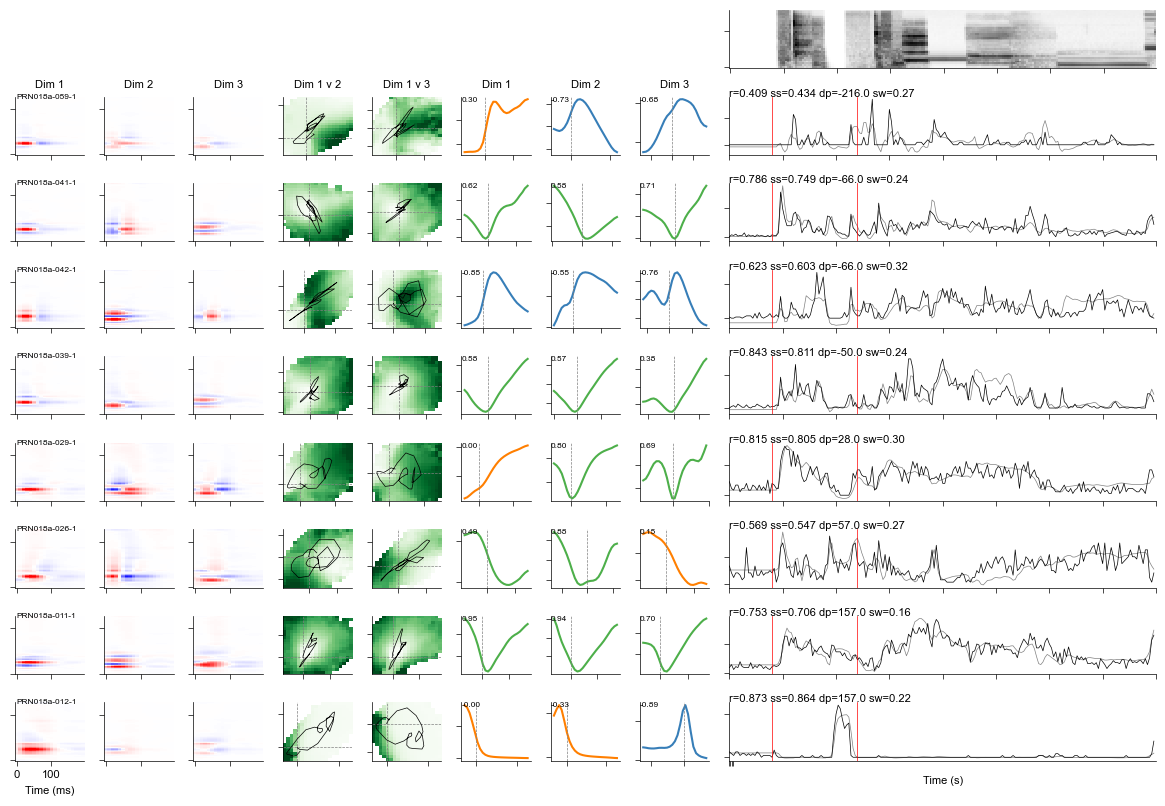

In [14]:
f=aud_ss_tools.plot_dpc_rows(modelspec=modelspec, est=est, val=val, emax=200000, w=11, df=df, cell_list=ns_cellids, verbose=False);

# Fig 4 - subspace similarity and SSRF overlap


## 4D. example site (also Extended Data Fig. 8)

In [15]:
Nmin = 5
rthr=0.3

cell_list_all = [c for o, c in enumerate(modelspec.meta['cellids']) if
             (modelspec.meta['r_test'][o, 0] > rthr) ]
cell_list = [c for o, c in enumerate(modelspec.meta['cellids']) if
             (modelspec.meta['r_test'][o, 0] > rthr)]
outline_colors=['r' if (df.loc[c,'celltype'][:1]=='N') else 'k'
                for o, c in enumerate(modelspec.meta['cellids'])]
fill_colors = [[aud_ss_tools.CB_color_cycle[ii % len(aud_ss_tools.CB_color_cycle)]] * 2 for ii in range(len(cell_list))]
outline_colors = [c for o,c in enumerate(outline_colors) if (modelspec.meta['r_test'][o, 0] > rthr)]
fill_colors = None
outline_colors = None

In [16]:
importlib.reload(aud_ss_tools)

<module 'aud_ss_tools' from '/auto/users/svd/projects/pub_data_share/wingert_2025/aud_ss_tools.py'>

[aud_ss_tools INFO] ** Recording raw:
[aud_ss_tools INFO]    SS proj oi=0 o=0 PRN018a-003-1 pc_count=3:
[aud_ss_tools INFO] 10 max olap [4, 5, 4] shuff [3, 3, 4]
[aud_ss_tools INFO] 20 max olap [5, 6, 5] shuff [4, 5, 5]
[aud_ss_tools INFO] 30 max olap [6, 7, 6] shuff [6, 7, 7]
[aud_ss_tools INFO] 40 max olap [8, 10, 8] shuff [9, 8, 10]


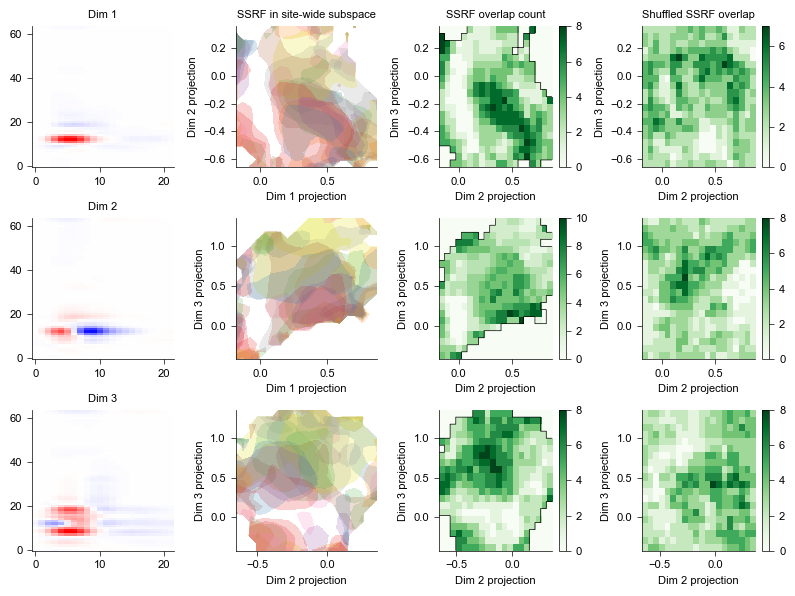

In [17]:
f, Zlist, Zshlist, Nlist, Nbins, Zall = aud_ss_tools.plot_common_dpc_space_2d(
    modelspec=modelspec, est=est, val=val,                 
    cell_list=cell_list, modelspec2=None, show_preds=True, plot_stim=True,
    use_val=False, emax=10000, level=[0.8], ex_pct=0.5,
    use_dpc_all=True, return_stats=True, Nmin=Nmin,
    fill_colors=fill_colors, outline_colors=outline_colors)


## 4E, 4G. Overlap summary and SSRF size

SSRFs are no more likely to overlap than a random distribution of SSRFs. SSRFs for narrow-spiking neurons (N) are larger than for regular-spiking neurons (R)

In [18]:
doverlap = pd.read_csv("ssrf_size_overlap.csv", index_col=0)

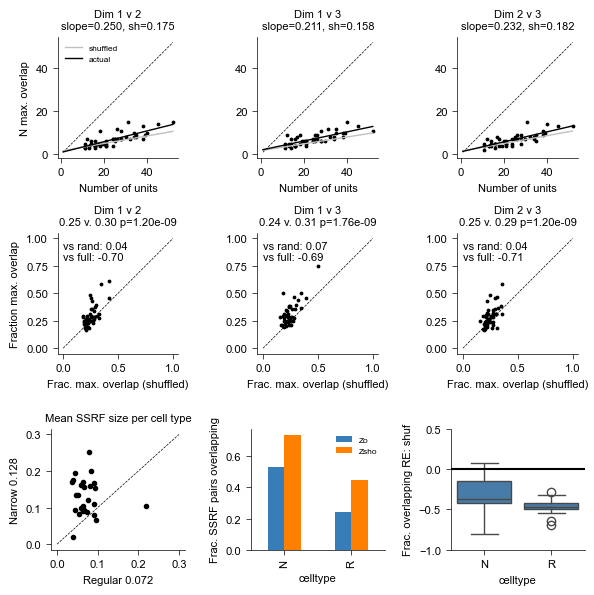

In [19]:
f, ax = plt.subplots(3, 3, figsize=(6, 6))
titles = ['Dim 1 v 2', 'Dim 1 v 3', 'Dim 2 v 3']
paircols = ['Z12','Z13','Z23']
shpaircols = ['Z12sh','Z13sh','Z23sh']
colors = ['silver', 'black']
types0 = ['N','R']

celltype = 'all'   # can also be 'R' or 'N'
doverlap_ = doverlap.loc[doverlap.celltype==celltype]
cellcount_max = doverlap['cellcount'].max()

for i, (a, a2) in enumerate(zip(ax[0,:3], ax[1,:3])):
    a.scatter(doverlap_['cellcount'], doverlap_[paircols[i]], s=3, color=colors[1])
    a.plot([1, cellcount_max], [1, cellcount_max], 'k--', lw=0.5)
    
    reg0 = linregress(doverlap_['cellcount'], doverlap_[shpaircols[i]])
    x = np.array([1, cellcount_max])
    y0 = reg0.slope * x + reg0.intercept
    a.plot(x, y0, color=colors[0], lw=1, label='shuffled')

    reg = linregress(doverlap_['cellcount'], doverlap_[paircols[i]])
    y = reg.slope * x + reg.intercept
    a.plot(x, y, color=colors[1], lw=1, label='actual')
    a.set_xlabel('Number of units')
    a.set_aspect('equal', 'box')
    a.set_title(f"{titles[i]}\nslope={reg.slope:.3f}, sh={reg0.slope:.3f}")
    
    xx0=doverlap_[shpaircols[i]]/doverlap_['cellcount']
    xx=doverlap_[paircols[i]]/doverlap_['cellcount']
    res = wilcoxon(xx-xx0, 1-xx, alternative='less')
    a2.scatter(xx0, xx, s=3, color=colors[1])
    a2.plot([0, 1], [0,1], 'k--', lw=0.5)
    a2.set_xlabel('Frac. max. overlap (shuffled)')
    a2.set_aspect('equal', 'box')
    a2.set_title(f"{titles[i]}\n{xx0.mean():.2f} v. {xx.mean():.2f} p={res.pvalue:.2e}")
    a2.text(0,0.8,f"vs rand: {np.mean(xx-xx0):.2f}\nvs full: {np.mean(xx-1):.2f}")

ax[0,0].set_ylabel('N max. overlap')
ax[0,0].legend()
ax[1,0].set_ylabel('Fraction max. overlap')

doverlap_ = doverlap.loc[doverlap.celltype.isin(types0)].copy()
doverlap_ = doverlap.copy()

for s1,s2 in zip(paircols,shpaircols):
    doverlap_[s1+'rat'] = (doverlap_[s1] - doverlap_[s2])/doverlap_[s2]
doverlap_['Zorat'] = (doverlap_['Zo'] - doverlap_['Zsho']) / doverlap_['Zsho']

d = doverlap_.loc[doverlap_.celltype.isin(types0)].groupby(['siteid','celltype'])['msize'].mean().unstack(-1).dropna()
dc = doverlap_.loc[doverlap_.celltype.isin(types0)].groupby(['siteid','celltype'])['cellcount'].sum().unstack(-1).dropna()
aud_ss_tools.scatter_comp(data=d,x='R',y='N', n1='Regular', n2='Narrow', ax=ax[2,0], hist_range=[0,0.3])
ax[2,0].set_title("Mean SSRF size per cell type")

doverlap_.groupby('celltype')[['Zo', 'Zsho']].mean().loc[types0].plot.bar(ax=ax[2,1])
ax[2,1].set_ylabel('Frac. SSRF pairs overlapping')

sns.boxplot(doverlap_, x='celltype', y='Zorat', order=types0, ax=ax[2,2])
ax[2,2].set_ylim([-1,0.5])
ax[2,2].axhline(0, color='k')
ax[2,2].set_ylabel('Frac. overlapping RE: shuf')

plt.tight_layout()

# Fig 5 - Subspace similarity, dependence on cell spike width and cortical layer

In [20]:
df_pair_sim = pd.read_csv("neuron_pair_similarity.csv", index_col=0)

df_pair_sim['wid1']=df_pair_sim['celltype1'].str.slice(0,1)
df_pair_sim['wid2']=df_pair_sim['celltype2'].str.slice(0,1)

swapin = ['depth1','depthcat1','wid1','celltype1','cellid1','siteid1','r_test1','CNN32-bsg_ceil','spont_mean', 'evoked_mean']
swapout = ['depth2','depthcat2','wid2','celltype2','cellid2','siteid2','r_test2','CNN32-bsg_ceil2','spont_mean2', 'evoked_mean2']
opwid = ((df_pair_sim.wid1=='N') & (df_pair_sim.wid2=='R')) | \
    ((df_pair_sim.wid1=='R') & (df_pair_sim.wid2=='R') & (df_pair_sim.depth1<df_pair_sim.depth2)) | \
    ((df_pair_sim.wid1=='N') & (df_pair_sim.wid2=='N') & (df_pair_sim.depth1<df_pair_sim.depth2))

df_pair_sim.loc[opwid, swapin+swapout] = df_pair_sim.loc[opwid, swapout+swapin].values
df_pair_sim['t1']=df_pair_sim['wid1'] + df_pair_sim['depthcat1'].astype(str)
df_pair_sim['t2']=df_pair_sim['wid2'] + df_pair_sim['depthcat2'].astype(str)
df_pair_sim['animal'] = df_pair_sim['cellid1'].str.slice(0,3)
df_pair_sim['siteid'] = df_pair_sim['cellid1'].apply(lambda x: x.split("-")[0])

md=800
area='A1'
rthr=0.12
ff= df_pair_sim['same_site'] & (df_pair_sim['depthcat1']<md) & \
   (df_pair_sim['depthcat2']<md) & (df_pair_sim['r_test']>rthr) & (df_pair_sim['area']==area)
df_pair_sim0 = df_pair_sim.copy()
df_pair_sim = df_pair_sim.loc[ff]

print(df_pair_sim.shape, df_pair_sim0.shape)

(42169, 45) (69259, 45)


## 5A. Example site - subspace similarity heatmap

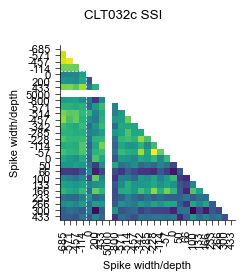

In [21]:
siteid="LMD052a"
siteid="PRN018a"
siteid="CLT032c"
stat='sscc'

singlesiteid = (df_pair_sim.siteid1==siteid) & (df_pair_sim.same_site==True)
dfsingsite = df_pair_sim.loc[singlesiteid].copy()
dfsingsite['t1']=(df_pair_sim['wid1']=='R')*10000 + df_pair_sim['depth1']
dfsingsite['t2']=(df_pair_sim['wid2']=='R')*10000 + df_pair_sim['depth2']

tidx = np.sort(pd.concat([dfsingsite['t1'], dfsingsite['t2']]).unique())

ds = dfsingsite.groupby(['t1','t2'])[stat].mean()
ds.loc[(5000,5000)]=np.nan
for t in tidx:
    ds.loc[(t,t)]=np.nan
ds=ds.unstack(-1)
mmax=np.nanmax(ds.values)
mmin=np.nanmin(ds.values)

midpos=3.5

f,ax=plt.subplots(figsize=(2.5,2.75))

t_ = np.sort(np.concatenate((tidx,[5000])))
tlabels = t_.copy()
tlabels[tlabels>5000]=tlabels[tlabels>5000]-10000

d_=ds.loc[t_,t_]
im=ax.imshow(d_.values, aspect='equal', vmin=mmin, vmax=mmax)
#plt.colorbar(im)

ax.axhline(midpos,color='white',linestyle='--',lw=0.5)
ax.axvline(midpos,color='white',linestyle='--',lw=0.5)
ax.set_yticks(np.arange(len(t_)),tlabels)
ax.set_xticks(np.arange(len(t_)),tlabels, rotation=90);
ax.set_xlabel('Spike width/depth')
ax.set_ylabel('Spike width/depth')
f.suptitle(f"{siteid} SSI")
plt.tight_layout()

## 5B. SSI spike width/cortical layer summary heatmaps

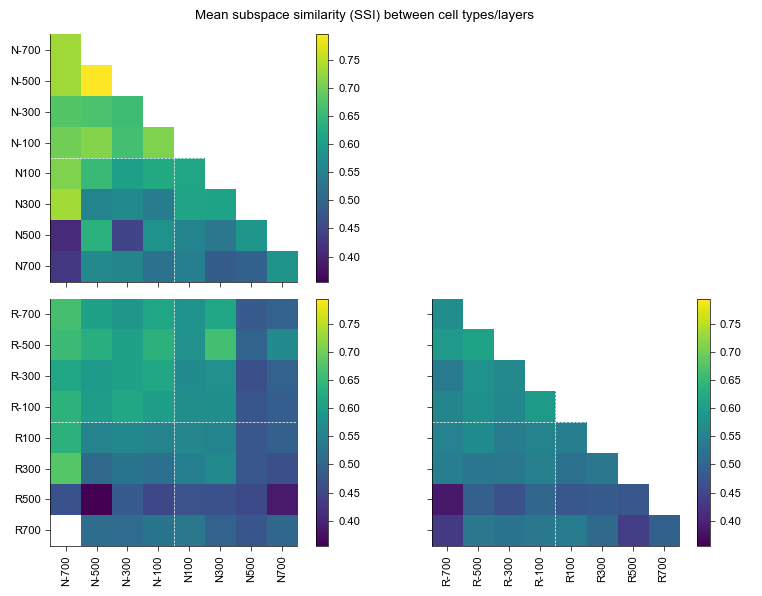

In [22]:
ud = np.sort(df_pair_sim.depthcat1.unique())
Nidx = [f"N{d}" for d in ud]
Ridx = [f"R{d}" for d in ud]
tidx = Nidx+Ridx

stat='sscc'
ds = df_pair_sim.groupby(['t1','t2'])[stat].mean()
ds=ds.unstack(-1)
mmax=np.nanmax(ds.values)
mmin=np.nanmin(ds.values)
midpos=3.5

f,ax=plt.subplots(2,2, sharex='col', sharey='row')

d_=ds.loc[Nidx,Nidx]
im=ax[0,0].imshow(d_.values, aspect='equal', vmin=mmin, vmax=mmax)
ax[0,0].set_yticks(np.arange(len(Nidx)),Nidx)
plt.colorbar(im)
ax[0,0].axhline(midpos,color='white',linestyle='--',lw=0.5)
ax[0,0].axvline(midpos,color='white',linestyle='--',lw=0.5)
d_=ds.loc[Ridx,Nidx]
im=ax[1,0].imshow(d_.values, aspect='equal', vmin=mmin, vmax=mmax)
ax[1,0].set_yticks(np.arange(len(Ridx)),Ridx)
ax[1,0].set_xticks(np.arange(len(Nidx)),Nidx, rotation=90)
ax[1,0].axhline(midpos,color='white',linestyle='--',lw=0.5)
ax[1,0].axvline(midpos,color='white',linestyle='--',lw=0.5)
plt.colorbar(im)
d_=ds.loc[Ridx,Ridx]
im=ax[1,1].imshow(d_.values, aspect='equal', vmin=mmin, vmax=mmax)
plt.colorbar(im)
ax[1,1].set_xticks(np.arange(len(Ridx)),Ridx, rotation=90);
ax[1,1].axhline(midpos,color='white',linestyle='--',lw=0.5)
ax[1,1].axvline(midpos,color='white',linestyle='--',lw=0.5)

ax[0,1].set_axis_off()
f.suptitle(f"Mean subspace similarity (SSI) between cell types/layers");
plt.tight_layout()

## Regression

In [23]:
rthr=0.15
area=['A1','PEG']
#area=['A1']
ff= df_pair_sim0['same_site'] & (df_pair_sim0['depthcat1']<md) & (df_pair_sim0['depthcat2']<md) & \
    (df_pair_sim0['r_test']>rthr) & (df_pair_sim0['area'].isin(area))
d = df_pair_sim0.loc[ff].copy()
print(f"rthr={rthr} keeping {ff.sum()}/{len(df_pair_sim0)} pairs")
depvar='respcc'
depvar='predcc'
depvar='sscc'

cols = [depvar, 'wid1','wid2','depthcat1','depthcat2','depth1','depth2','r_test1','r_test2','r_test','evoked_mean','evoked_mean2','spont_mean','spont_mean2','celltype1','celltype2','cellid1','cellid2','animal','siteid']
cols2 = [depvar, 'wid2','wid1','depthcat2','depthcat1','depth2','depth1','r_test2','r_test1','r_test','evoked_mean2','evoked_mean','spont_mean2','spont_mean','celltype2','celltype1','cellid2','cellid1','animal','siteid']

d = d[cols].copy()

d2=d[cols2].copy()
d2.columns=cols
d['dup']=False
d2['dup']=True
#d=pd.concat([d,d2],ignore_index=True)
d['r_test']=(d['r_test1']+d['r_test2'])/2
d = d[cols].copy()
d['mean_depth']=(d['depth1']+d['depth2'])/2
d['diff_depth']=np.abs(d['depth1']-d['depth2'])

depth_norm=d['mean_depth'].std()
#depth_norm = d['depthcat1'].std()
#d['depthcat1']=d['depthcat1']/depth_norm
#d['depthcat2']=d['depthcat2']/depth_norm
d['depth1']=d['depth1']/depth_norm
d['depth2']=d['depth2']/depth_norm
d['mean_depth']=d['mean_depth']/depth_norm
d['diff_depth']=d['diff_depth']/depth_norm

r_test_norm=d['r_test'].std()
d['r_test1']=d['r_test1']/r_test_norm
d['r_test2']=d['r_test2']/r_test_norm
d['r_test']=d['r_test']/r_test_norm

evoked_norm=d['evoked_mean'].std()
d['evoked_mean2']=d['evoked_mean2']/evoked_norm
d['evoked_mean']=d['evoked_mean']/evoked_norm
d['mean_mean']=(d['evoked_mean']+d['evoked_mean2'])/2

d['wid'] = d['wid1']+d['wid2']
d['samelayer']=d['depthcat1']==d['depthcat2']

formula=f"{depvar} ~ C(wid) + depth1 + depth2 + C(wid)*depth1 + C(wid)*depth2 + r_test + evoked_mean + evoked_mean2"
formula=f"{depvar} ~ C(wid1) + C(wid2) + depth1 + depth2 + C(wid1)*depth1 + C(wid2)*depth2 + r_test + evoked_mean + evoked_mean2"
formula=f"{depvar} ~ C(wid) + depth1 + depth2 + C(wid)*depth1 + C(wid)*depth2 + r_test + evoked_mean + evoked_mean2 + C(animal)"
formula=f"{depvar} ~ C(wid1) + C(wid2) + depth1 + depth2 + C(wid1)*depth1 + C(wid2)*depth2 + r_test + evoked_mean + evoked_mean2 + C(animal)"
formula=f"{depvar} ~ C(wid) + mean_depth + diff_depth + C(wid)*mean_depth + C(wid)*diff_depth + r_test + mean_mean + C(animal)"

formula2=f"{depvar} ~ C(wid) + mean_depth + diff_depth + C(wid)*mean_depth + C(wid)*diff_depth + r_test + mean_mean + C(animal)"

model = smf.ols(data=d, formula=formula).fit()
model2 = smf.ols(data=d, formula=formula2).fit()

model.summary()

rthr=0.15 keeping 60973/69259 pairs


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   sscc   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     855.7
Date:                Wed, 21 Jan 2026   Prob (F-statistic):               0.00
Time:                        17:21:38   Log-Likelihood:                 29088.
No. Observations:               60973   AIC:                        -5.815e+04
Df Residuals:                   60959   BIC:                        -5.802e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   0.7077      0.006    114.342      0.000       0.696       0.720
C(wid)[T.RN]               -0.0740      0.006    -12.540      0.000      -0.086      -0.062
C(wid)[T.RR]               -0.1079      0.006    -18.866      0.000      -0.119      -0.097
C(animal)[T.LMD]            0.0429      0.002     20.647      0.000       0.039       0.047
C(animal)[T.PRN]            0.0759      0.002     44.941      0.000       0.073       0.079
C(animal)[T.SLJ]           -0.0202      0.002     -8.276      0.000      -0.025      -0.015
mean_depth                 -0.0507      0.003    -17.034      0.000      -0.057      -0.045
C(wid)[T.RN]:mean_depth     0.0115      0.003      3.590      0.000       0.005       0.018
C(wid)[T.RR]:mean_depth     0.0348      0.003     11.313      0.000       0.029       0.041
diff_depth                 -0.0293      0.003     -9.571      0.000      -0.035      -0.023
C(wid)[T.RN]:diff_depth     0.0064      0.003      1.977      0.048     5.5e-05       0.013
C(wid)[T.RR]:diff_depth     0.0105      0.003      3.332      0.001       0.004       0.017
r_test                     -0.0401      0.001    -56.324      0.000      -0.042      -0.039
mean_mean                  -0.0026      0.001     -3.248      0.001      -0.004      -0.001
==============================================================================
Omnibus:                      926.516   Durbin-Watson:                   0.944
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              993.237
Skew:                          -0.285   Prob(JB):                    2.10e-216
Kurtosis:                       3.258   Cond. No.                         61.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 5C-D. Depth vs. SSI curves 

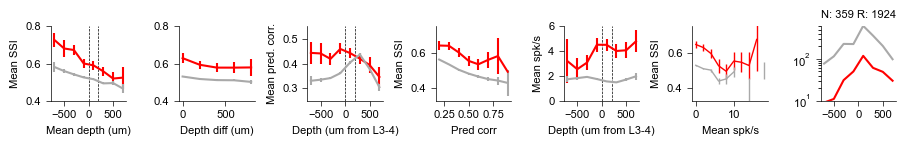

In [24]:
depvar='sscc'
c2='r_test'
cols=[f'{depvar}',f'{depvar}_pred','r_test','evoked_mean','spont_mean']
rthr2=0.15

#ff = (np.abs(d['depthcat1']-d['depthcat2'])<=200) & (d['wid1']==d['wid2']) # & (d['dup']==False)
ff = (d['wid1']==d['wid2']) & (d['r_test']>rthr2/r_test_norm) # & (d['dup']==True)
ff = (d['r_test']>rthr2/r_test_norm) # & (d['dup']==True)

d_ = d.loc[ff].copy()
d_[f'{depvar}_pred'] = model2.predict(d_)

d_['cellcat']=d['wid']
d_['depthcat1']=d_['depthcat1']
d_['r_test']=np.round(d_['r_test']*r_test_norm,1)
d_['evoked_mean']=np.round((d_['evoked_mean']*evoked_norm+d_['spont_mean'])*50)*2

dn_ = d_[['cellid1','depthcat1','cellcat']].drop_duplicates()
dn_=dn_.groupby(['depthcat1','cellcat']).count().unstack(-1)

dre_=d_.groupby(['r_test','cellcat'])[cols].sem().unstack(-1)*3
dr_=d_.groupby(['r_test','cellcat'])[cols].mean().unstack(-1)
dme_=d_.groupby(['evoked_mean','cellcat'])[cols].sem().unstack(-1)*3
dm_=d_.groupby(['evoked_mean','cellcat'])[cols].mean().unstack(-1)

#de_=d_.groupby(['depthcat1','cellcat'])[cols].sem().unstack(-1)*3
#d_=d_.groupby(['depthcat1','cellcat'])[cols].mean().unstack(-1)

d_['depth_diff'] = np.abs(d_['depthcat1']-d_['depthcat2'])
d_['depth_mean'] = np.round((d_['depth1']+d_['depth2'])*depth_norm/2/200-0.5)*200+100
dde_=d_.loc[d_['depth_diff']<1000].groupby(['depth_diff','cellcat'])[cols].sem().unstack(-1)*3
dd_=d_.loc[d_['depth_diff']<1000].groupby(['depth_diff','cellcat'])[cols].mean().unstack(-1)

de_=d_.loc[d_['depth_diff']<1000].groupby(['depth_mean','cellcat'])[cols].sem().unstack(-1)*3
d_=d_.loc[d_['depth_diff']<1000].groupby(['depth_mean','cellcat'])[cols].mean().unstack(-1)

N=7
sf=1.0
f,ax = plt.subplots(1,N,figsize=(N*1.3*sf,1.5*sf))
ax[0].errorbar(d_.index,d_[depvar].values[:,0],de_[depvar].values[:,0],color='red')
ax[0].errorbar(d_.index,d_[depvar].values[:,2],de_[depvar].values[:,2],color='darkgray')
#ax[0].plot(d_.index,d_[f'{depvar}_pred'].values[:,0],'--',color='red')
#ax[0].plot(d_.index,d_[f'{depvar}_pred'].values[:,1],'--',color='darkgray')
ax[0].axvline(0, color='k', linestyle='--', lw=0.5)
ax[0].axvline(200, color='k', linestyle='--', lw=0.5)
ax[0].set_xlabel('Mean depth (um)')
if depvar=='sscc':
    ax[0].set_ylim([0.4,0.8])
else:
    ax[0].set_ylim([0,0.4])
ax[0].set_ylabel('Mean SSI')

ax[1].errorbar(dd_.index,dd_[depvar].values[:,0],dde_[depvar].values[:,0],color='red')
ax[1].errorbar(dd_.index,dd_[depvar].values[:,2],dde_[depvar].values[:,2],color='darkgray')
#ax[1].plot(dd_.index,dd_[f'{depvar}_pred'].values[:,0],'--',color='red')
#ax[1].plot(dd_.index,dd_[f'{depvar}_pred'].values[:,1],'--',color='darkgray')
ax[1].set_xlabel('Depth diff (um)')
if depvar=='sscc':
    ax[1].set_ylim([0.4,0.8])
else:
    ax[1].set_ylim([0,0.4])


ax[2].errorbar(d_.index,d_[c2].values[:,0],de_[c2].values[:,0],color='red')
ax[2].errorbar(d_.index,d_[c2].values[:,2],de_[c2].values[:,2],color='darkgray')
ax[2].axvline(0, color='k', linestyle='--', lw=0.5)
ax[2].axvline(200, color='k', linestyle='--', lw=0.5)
ax[2].set_xlabel('Depth (um from L3-4)')
ax[2].set_ylim([0.25,0.55])
ax[2].set_ylabel('Mean pred. corr.')

ax[3].errorbar(dr_.index,dr_[depvar].values[:,0],dre_[depvar].values[:,0],color='red')
ax[3].errorbar(dr_.index,dr_[depvar].values[:,2],dre_[depvar].values[:,2],color='darkgray')
#ax[3].plot(dr_.index,dr_[f'{depvar}_pred'].values[:,0],'--',color='red')
#ax[3].plot(dr_.index,dr_[f'{depvar}_pred'].values[:,1],'--',color='darkgray')
ax[3].set_xlabel('Pred corr')
ax[3].set_ylim([0.33,0.75])
ax[3].set_ylabel('Mean SSI')

c3='evoked_mean'
ax[4].errorbar(d_.index,d_[c3].values[:,0],de_[c3].values[:,0],color='red')
ax[4].errorbar(d_.index,d_[c3].values[:,2],de_[c3].values[:,2],color='darkgray')
ax[4].axvline(0, color='k', linestyle='--', lw=0.5)
ax[4].axvline(200, color='k', linestyle='--', lw=0.5)
ax[4].set_xlabel('Depth (um from L3-4)')
ax[4].set_ylim([0,6])
ax[4].set_ylabel('Mean spk/s')

ax[5].errorbar(dm_.index,dm_[depvar].values[:,0],dme_[depvar].values[:,0],lw=1, color='red')
ax[5].errorbar(dm_.index,dm_[depvar].values[:,2],dme_[depvar].values[:,2],lw=1, color='darkgray')
#ax[5].plot(dm_.index,dm_[f'{depvar}_pred'].values[:,0],'--',lw=1, color='red')
#ax[5].plot(dm_.index,dm_[f'{depvar}_pred'].values[:,2],'--',lw=1, color='darkgray')
ax[5].set_xlabel('Mean spk/s')
ax[5].set_ylim([0.33,0.75])
ax[5].set_ylabel('Mean SSI')

ax[-1].semilogy(d_.index,dn_['cellid1'].values[:,0],color='red')
ax[-1].semilogy(d_.index,dn_['cellid1'].values[:,1],color='darkgray')
ax[-1].set_title(f"N: {dn_['cellid1'].values[:,0].sum()} R: {dn_['cellid1'].values[:,1].sum()}")
ax[-1].set_ylim(10,600)
plt.tight_layout()

# Fig 6 - Tuning symmetry (TSI) vs. cell type

In [25]:
tsi_data = pd.read_csv(f"neuron_ss_tuning_pcs.csv", index_col=0)


In [26]:
tsi_data=tsi_data.loc[tsi_data['area'].isin(['A1','PEG'])]
tsi_data['layer'] = 'L4'
tsi_data.loc[tsi_data['depthcat']<0,'layer']='L13'
tsi_data.loc[tsi_data['depthcat']>200,'layer']='L56'
tsi_data['width'] = 'R'
tsi_data.loc[tsi_data['narrow'],'width'] = 'N'
tsi_data['layer_wid']=tsi_data['width']+tsi_data['layer']
typecode={-1: 'n', 0: 'z', 1: 'p'}
tsi_data['sstype']=tsi_data['asym_cat'].apply(lambda x: typecode[x])+tsi_data['layer']


## 6A. Histograms of TSI for different cell types.

pc var threshold: 11161/11161


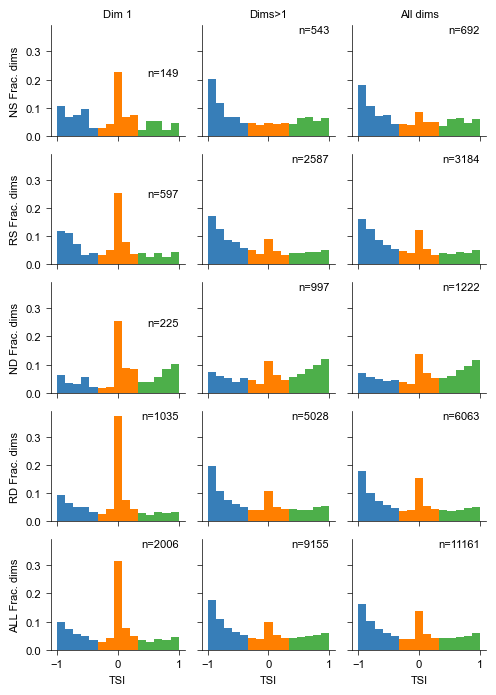

In [27]:
f2,ax=plt.subplots(5,3,figsize=(5,7), sharex='col', sharey=True)
types = ['NS', 'RS', 'ND', 'RD','ALL']
bd=0.3

# uncomment to exclude weak variance dims
#print(f"ystd threshold: {np.sum(tsi_data['ystd']>=1)}/{len(tsi_data)}")
#tsi_data.loc[tsi_data['ystd']<1,'ystd']=np.nan

# include filters for ss dims that contribute to thrcol fraction of total dSTRF variance
# and only include cells with prediction accuracy > 0.15
thrcol = '0.8'
namecol = 'CNN32-bsg'
print(f"pc var threshold: {np.sum((tsi_data['pci']<=tsi_data[thrcol]) & (tsi_data[namecol]>=0.15))}/{len(tsi_data)}")
tsi_data.loc[(tsi_data['pci']>tsi_data[thrcol]) | (tsi_data[namecol]<0.15),'ystd']=np.nan

pclabels = ['Dim 1', 'Dims>1', 'All dims']
for p1 in range(3):
    bins=np.linspace(-1,1,16)
    for tt,type in enumerate(types):
        #asym = tsi_data.loc[(df_poly['pci']==p1) & (tsi_data['celltype']==type) & (tsi_data['area']=='A1'),'asym']
        if p1==0:
            if type=='ALL':
                asym = tsi_data.dropna().loc[(tsi_data['pci']==p1),'asym']
            else:
                asym = tsi_data.dropna().loc[(tsi_data['pci']==p1) & (tsi_data['celltype']==type),'asym'] 
        elif p1==1:
            if type=='ALL':
                asym = tsi_data.dropna().loc[(tsi_data['pci']>=p1),'asym']
            else:
                asym = tsi_data.dropna().loc[(tsi_data['pci']>=p1) & (tsi_data['celltype']==type),'asym']
        else:
            if type=='ALL':
                asym = tsi_data.dropna()['asym']
            else:
                asym = tsi_data.dropna().loc[(tsi_data['celltype']==type),'asym']
                
        n, e = np.histogram(asym, bins=bins)
        ec=(e[:-1]+e[1:])/2
        n = n/n.sum()
        ax[tt,p1].bar(ec[ec<-bd],n[ec<-bd], width=ec[2]-ec[1])
        ax[tt,p1].bar(ec[np.abs(ec)<bd],n[np.abs(ec)<bd], width=ec[2]-ec[1])
        ax[tt,p1].bar(ec[ec>bd],n[ec>bd], width=ec[2]-ec[1])
        if p1==1:
            ax[tt,p1].set_ylim(ax[tt,0].get_ylim())
            ax[tt,0].set_ylabel(f"{type} Frac. dims")
        ax[tt,p1].text(1,ax[tt,p1].get_ylim()[1],f"n={len(asym)}", ha='right', va='top')
    ax[0,p1].set_title(pclabels[p1])
    ax[-1,p1].set_xlabel("TSI")
plt.tight_layout()


In [28]:
t=tsi_data.groupby(['area','width','cellid'])['layer_wid'].count().reset_index()
t.groupby(['area','width']).count()

cellid  layer_wid
area width                   
A1   N         310        310
     R        1246       1246
PEG  N          64         64
     R         386        386

## 6B. TSI vs. depth

In [29]:
d1=tsi_data.copy()


0.053, 0.037, 0.018
[0.76399964 0.75719022 0.75727981]


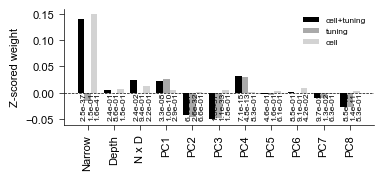

In [30]:
pcmin=0
pcmax=15
npc=16
pcols = [f"PC{i+1}" for i in range(npc)]

d2 = d1.copy()
d2['N'] = np.random.permutation(d2['N'])
d2['D'] = np.random.permutation(d2['D'])
d3 = d1.copy()
for c in pcols:
    d3[c] = np.random.permutation(d3[c])
    
col='pos'
Nfitpc=8
formula=f"{col} ~ C(N) + D + C(N)*D + " + " + ".join(pcols[:Nfitpc])
#formula=f"{col} ~ depth + sw + sw*depth + " + " + ".join(pcols)
#formula=f"{col} ~ D + C(N) + " + " + ".join(pcols)
#formula=f"{col} ~ D + C(N) + C(N)*D"

data_ = [d1,d2,d3]
models = [smf.ols(formula=formula, data=d) for d in data_]
#models = [smf.logit(formula=formula, data=d) for d in data_]
results = [m.fit() for m in models]
preds = np.stack([r.predict(d) for r,d in zip(results,data_)], axis=1)
acts = np.stack([d[col] for d in data_], axis=1)

pnames = list(results[0].params.index)
pnames[1]='Narrow'
pnames[2]='Depth'
pnames[3]='N x D'
for r in results:
    r.params = pd.Series(r.params.values, index=pnames)
    r.pvalues = pd.Series(r.pvalues.values, index=pnames)
    
f,ax=plt.subplots(1,1,figsize=(4,1.5), sharex='col')
labels=['cell+tuning','tuning','cell']
colors = ['black','darkgray','lightgray']
for ii,(r,l) in enumerate(zip(results[:3],labels[:3])):
    ax.bar(np.arange(len(r.params)-1)+ii/4-0.25, r.params[1:],width=0.25, color=colors[ii], label=l)

    for jj, pp in enumerate(r.pvalues[1:]):
        ax.text(jj+ii/4-0.25,-0.05,f"{pp:.1e}", fontsize=6,rotation=90)
    
    #ax[1].plot(np.log(r.pvalues[1:]), label=l)
ax.axhline(0, linestyle='--', lw=0.5, color='k')
ax.set_xticks(np.arange(len(pnames)-1),pnames[1:], rotation=90)
ax.set_ylabel('Z-scored weight')
plt.legend()

print(", ".join([f"{r.rsquared_adj:.3f}" for r in results]))
#print(f"r=[{res.prsquared:.4f}, {res1.prsquared:.4f}, {res2.prsquared:.4f}]")
print(((preds>0.5)==acts).mean(axis=0))

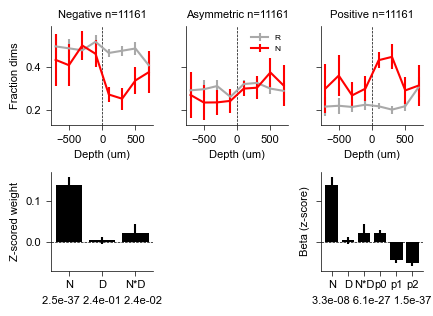

In [31]:
pcmin=0
pcmax=15
npc=16
d_ = tsi_data.copy()

d_['depthcat'] = (np.round(d_['depth'].astype(float)/200-0.5)*200+100).astype(int)
#pcmin=0
#d_=d_.loc[np.isfinite(dfp['ystd']) & (d_['depthcat']<900) & (d_['pci']>=pcmin)]
d_=d_.loc[np.isfinite(d_['ystd']) & (d_['depth']<800) & (d_['pci']>=pcmin)]

cols=['Negative','Asymmetric','Positive']
d_['Negative'] = d_['asym_cat']==-1
d_['Asymmetric'] = d_['asym_cat']==0
d_['Positive'] = d_['asym_cat']==1
dc=d_.groupby(['depthcat','narrow'])[cols].count().unstack(-1)
de_=d_.groupby(['depthcat','narrow'])[cols].sem().unstack(-1)*2
d_=d_.groupby(['depthcat','narrow'])[cols].mean().unstack(-1)
f,ax=plt.subplots(2,3, figsize=(4.5,3.2), sharey='row')
for a,c in zip(ax[0,:],cols):
    a.errorbar(d_.index,d_[c].values[:,0],de_[c].values[:,0],color='darkgray', label='R')
    a.errorbar(d_.index,d_[c].values[:,1],de_[c].values[:,1],color='red', label='N')
    a.axvline(0, linestyle='--', lw=0.5, color='k')
    a.set_title(f"{c} n={dc[c].values.sum()}")
    a.set_xlabel('Depth (um)')
ax[0,0].set_ylabel('Fraction dims')
ax[0,1].legend()

labels = ['N','D','N*D'] + [f"p{i}" for i in range(npc)]

N=3
pv = results[0].pvalues[1:(N+1)].values
p = results[0].params[1:(N+1)].values
pstr = [f"{p_:.1e}" for p_ in pv]
bb = results[0].conf_int().values[1:(N+1)]
ee = np.abs(p[:,np.newaxis]-bb)
#ax[1,0].errorbar(labels[:N], p, ee.T, color='k')
#ax[1,0].errorbar(labels[:N], p, ee.T, color='k')
ax[1,0].errorbar(labels[:N], p, ee.T, linestyle='None', color='k')
ax[1,0].bar(labels[:N], p, color='k')
ax[1,0].axhline(0,linestyle='--',lw=0.5, color='k')
ax[1,0].set_ylabel('Z-scored weight')
ax[1,0].set_xlabel(" ".join(pstr))

N=6
pv = results[0].pvalues[1:(N+1)].values
p = results[0].params[1:(N+1)].values
pstr = [f"{p_:.1e}" for p_ in pv]
bb = results[0].conf_int().values[1:(N+1)]
ee = np.abs(p[:,np.newaxis]-bb)
ax[1,1].set_axis_off()

#ax[1,2].errorbar(labels[:N], p, ee.T, color='k')
ax[1,2].errorbar(labels[:N], p, ee.T, linestyle='None', color='k')
ax[1,2].bar(labels[:N], p, color='k')
ax[1,2].axhline(0,linestyle='--',lw=0.5, color='k')
ax[1,2].set_ylabel('Beta (z-score)')
ax[1,2].set_xlabel(" ".join(pstr[3:]))

plt.tight_layout()


## 6C. TSI fractions vs. cell type

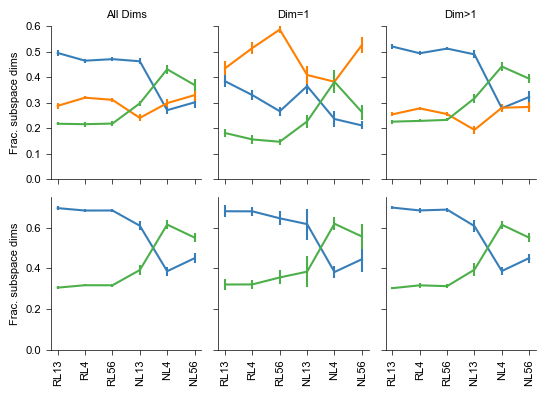

In [32]:
def error_comp(data, jcount=10, colors=None, ax=None, ordered_columns=None):
    cj = []
    ii = np.arange(len(data))
    for j in range(jcount):
        jj = np.setdiff1d(ii,ii[j::jcount])
        counts = data.iloc[jj].groupby(['asym_cat','layer_wid'])['cellid'].count().unstack(-1)
        if ordered_columns is not None:
            counts=counts[ordered_columns]
        counts = counts/counts.sum(axis=0)
        cj.append(counts)
    c = np.stack(cj, axis=2)
    mcounts = np.mean(c,axis=2)
    ecounts = np.std(c,axis=2) * np.sqrt(jcount-1)
    
    mcounts, ecounts
    
    x=np.repeat(np.arange(6)[:,np.newaxis],3, axis=1)
    x=np.arange(6)
    if ax is None:
        f,ax=plt.subplots()
    for y_,ye_,c_ in zip(mcounts,ecounts, colors):
        ax.errorbar(x,y_,ye_, color=c_)
    return ax

types=list(tsi_data['layer_wid'].unique())
types=['RL13', 'RL4', 'RL56', 'NL13', 'NL4', 'NL56' ]
sstypes=['nL13', 'nL4', 'nL56', 'zL13', 'zL4', 'zL56', 'pL13', 'pL4', 'pL56' ]
colors = [d['color'] for d in list(plt.rcParams['axes.prop_cycle'])]

f,ax=plt.subplots(2,3,figsize=(5.5,4), sharex='col', sharey='row')
error_comp(tsi_data, colors=colors, ordered_columns=types, ax=ax[0,0])
error_comp(tsi_data.loc[tsi_data['asym_cat']!=0], colors=[colors[0],colors[2]], ordered_columns=types, ax=ax[1,0])
ax[0,0].set_title('All Dims')
ax[1,0].set_xticks(np.arange(6), types, rotation=90)

error_comp(tsi_data.loc[(tsi_data['pci']==0)], ordered_columns=types, colors=colors, ax=ax[0,1])
error_comp(tsi_data.loc[(tsi_data['pci']==0) & (tsi_data['asym_cat']!=0)], ordered_columns=types, colors=[colors[0],colors[2]], ax=ax[1,1])
ax[0,1].set_title('Dim=1')

error_comp(tsi_data.loc[(tsi_data['pci']>0)], ordered_columns=types, colors=colors, ax=ax[0,2])
error_comp(tsi_data.loc[(tsi_data['pci']>0) & (tsi_data['asym_cat']!=0)], ordered_columns=types, colors=[colors[0],colors[2]], ax=ax[1,2])
ax[0,2].set_title('Dim>1')
ax[1,1].set_xticks(np.arange(6), types, rotation=90)

ax[0,0].set_ylim([0,0.6])
ax[0,0].set_ylabel('Frac. subspace dims')
ax[1,0].set_ylim([0,0.75])
ax[1,0].set_ylabel('Frac. subspace dims')
ax[1,2].set_xticks(np.arange(6), types, rotation=90)

plt.tight_layout()

## 6D. Heatmaps of TSI categories per cell

In [33]:
dfp=tsi_data.copy()
pci_max=5
rmin=0.1
cellids = list(dfp.loc[(dfp['r_test']>rmin) & (dfp['pci']==pci_max),'cellid'])
print(len(cellids))
dfp=dfp.loc[dfp['cellid'].isin(cellids) & (dfp['pci']<pci_max)]
print(dfp.shape)
#print(dfp.groupby('pci'))
dfn = dfp.groupby(['narrow','cellid','asym_cat'])[['pci']].count()
dfn.columns=['N']
#dfn=dfn.reset_index()
dfn=dfn.unstack(-1).fillna(0)
dcounts=dfn['N'].reset_index().groupby(['narrow',-1, 0, 1]).count().reset_index()
countsN = dcounts.loc[dcounts['narrow']].pivot(index=-1, columns=1, values='cellid')
countsR = dcounts.loc[dcounts['narrow']==False].pivot(index=-1, columns=1, values='cellid')

#actual_fracs = np.array([fracR[1:,0].sum(), fracR[0,1:].sum(), fracN[1:,0].sum(), fracN[0, 1:].sum()])
#print(np.nansum(countsN), np.nansum(countsR))

881
(4405, 50)


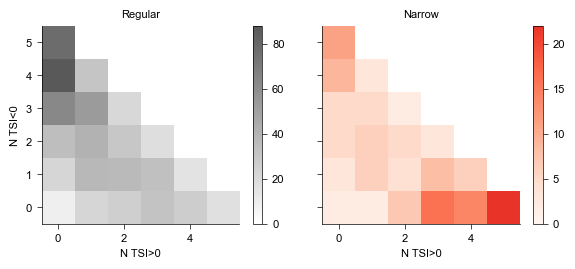

In [34]:
import matplotlib.colors as mcolors
min_val = 0.0
max_val = 0.65
n_colors = 256
f,ax=plt.subplots(1,2,figsize=(6,2.5), sharey='row')

original_cmap = plt.get_cmap("gray_r")
vv=original_cmap(np.linspace(min_val, max_val, n_colors))
truncated_cmap = mcolors.LinearSegmentedColormap.from_list(
    'truncated_gray_r', vv )

im=ax[0].imshow(countsR, aspect='equal', origin='lower', vmin=0, cmap=truncated_cmap);
plt.colorbar(im, ax=ax[0])

original_cmap = plt.get_cmap("Reds")
vv=original_cmap(np.linspace(min_val, max_val, n_colors))
truncated_cmap = mcolors.LinearSegmentedColormap.from_list(
    'truncated_Reds', vv )

im=ax[1].imshow(countsN, aspect='equal', origin='lower', vmin=0, cmap=truncated_cmap);
plt.colorbar(im, ax=ax[1])
ax[0].set_ylabel('N TSI<0')
ax[0].set_xlabel('N TSI>0')
ax[0].set_title('Regular')
ax[1].set_xlabel('N TSI>0')
ax[1].set_title('Narrow')

plt.tight_layout()

Count a few things

In [35]:
dm = d1.groupby(['area','narrow','cellid'])['asym'].mean().reset_index()
dm.groupby(['area','narrow']).count()


cellid  asym
area narrow              
A1   False     1246  1246
     True       310   310
PEG  False      386   386
     True        64    64

In [36]:
dm.groupby(['narrow']).count()

,area,cellid,asym
narrow,,,
False,1632,1632,1632
True,374,374,374


In [37]:
dp = d1.groupby(['area','narrow','cellid','pci'])['asym'].mean().reset_index()
dp.groupby(['area','narrow']).count()

cellid   pci  asym
area narrow                    
A1   False     6692  6692  6692
     True      1487  1487  1487
PEG  False     2555  2555  2555
     True       427   427   427

In [38]:
dp = d1.loc[d1['asym_cat'].isin([1,-1])].groupby(['area','narrow','cellid','pci'])['asym'].mean().reset_index()
dp.groupby(['area','narrow']).count()

cellid   pci  asym
area narrow                    
A1   False     4614  4614  4614
     True      1030  1030  1030
PEG  False     1798  1798  1798
     True       331   331   331